In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
drift_flat = pd.read_csv(r"C:\Users\conno.DESKTOP-98EBONR\OneDrive\Desktop\AI_ML\Log Data\drift_log_flat.csv")

In [3]:
drift_flat.head()

,timestamp,index,dx_ref_real,dy_ref_real,dx_ref_px,dy_ref_px,dx_step_px,dy_step_px,vx_px_s,vy_px_s,speed_px_s,anchored,suggested_k,ref_image,current_img
0,2026-04-04T18:20:04,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,7,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...
1,2026-04-04T18:20:11,1,-15.036387,20.047476,-15.036387,20.047476,-15.036387,20.047476,-2.173647,2.898046,3.622625,False,2,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...,20260404_182008_scan002_Au(111)_4k_STM_AUTO_(B...
2,2026-04-04T18:20:18,2,0.013444,0.059207,0.013444,0.059207,15.049831,-19.988269,0.022816,-0.024732,0.033649,False,50,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...,20260404_182015_scan003_Au(111)_4k_STM_AUTO_(B...
3,2026-04-04T18:20:26,3,0.008218,-0.951941,0.008218,-0.951941,-0.005226,-1.011148,-0.000673,-0.130166,0.130168,False,13,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...,20260404_182023_scan004_Au(111)_4k_STM_AUTO_(B...
4,2026-04-04T18:20:32,4,0.005027,0.068856,0.005027,0.068856,-0.003191,1.020798,-0.000576,0.011719,0.011733,False,50,20260404_182001_scan001_Au(111)_4k_STM_AUTO_(B...,20260404_182029_scan005_Au(111)_4k_STM_AUTO_(B...


In [4]:
dx = drift_flat['dx_ref_real'][0:15].values
dy = drift_flat['dy_ref_real'][0:15].values

In [5]:
dx

array([ 0.00000000e+00, -1.50363872e+01,  1.34440270e-02,  8.21846000e-03,
        5.02711500e-03,  4.23227850e-02,  1.07460521e+00, -4.08159320e-02,
       -4.18953090e-02, -4.06421126e+00, -1.11528665e+00,  8.98906126e-01,
        2.91768679e+00,  3.89606003e+00,  2.96901316e+00])

In [6]:
t = np.linspace(0,10,15)

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

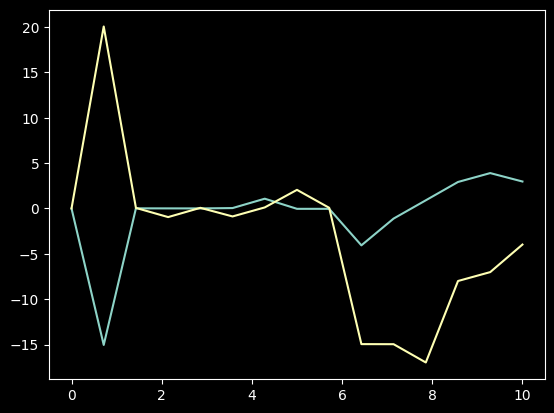

In [7]:
plt.plot(t,dx, label='drift x')
plt.plot(t,dy, label='drift y')
plt.legend

In [8]:
model = Sequential([
    Dense(32, activation='tanh', input_dim=1),
    Dense(32, activation='tanh'),
    Dense(128, activation ='relu'),
    Dense(8, activation ='linear'),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')

C:\Users\conno.DESKTOP-98EBONR\OneDrive\Desktop\GitHub Repo\PHYS441\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
x_train = dx.reshape(-1,1)
y_train = dy.reshape(-1,1)
t_reshaped= t.reshape(-1,1)

model.fit(t_reshaped,x_train,epochs=2500, verbose=1)

Epoch 1/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - loss: 19.1203
Epoch 2/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.6875
Epoch 3/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 18.3918
Epoch 4/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 18.2144
Epoch 5/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.1127
Epoch 6/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.0648
Epoch 7/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.0355
Epoch 8/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.0051
Epoch 9/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.9535
Epoch 10/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.8830
Epoch 11/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 17.7974
Epoch 12/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 17.7071
Epoch 13/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 17.6178
Epoch 14/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.5363
Epoch 15/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - lo

In [10]:
x_test = drift_flat['dx_ref_real'][16:].values
y_test = drift_flat['dy_ref_real'][16:].values

In [11]:
x_test

array([-1.02680132,  0.014722  , -2.95270124, -4.923383  , -3.91014736,
        1.03175254,  0.06716057, -0.92536649, -3.89667714, -0.85986953])

In [12]:
predict = model.predict(x_test)
t_test =np.linspace(0,10, 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [13]:
predict


array([[24.434395  ],
       [-0.50217295],
       [31.86199   ],
       [32.735172  ],
       [32.45578   ],
       [-4.6177506 ],
       [-2.1910918 ],
       [23.090488  ],
       [32.45118   ],
       [22.129375  ]], dtype=float32)

In [17]:
x_test

array([-1.02680132,  0.014722  , -2.95270124, -4.923383  , -3.91014736,
        1.03175254,  0.06716057, -0.92536649, -3.89667714, -0.85986953])

[[24.434395  ]
 [-0.50217295]
 [31.86199   ]
 [32.735172  ]
 [32.45578   ]
 [-4.6177506 ]
 [-2.1910918 ]
 [23.090488  ]
 [32.45118   ]
 [22.129375  ]]


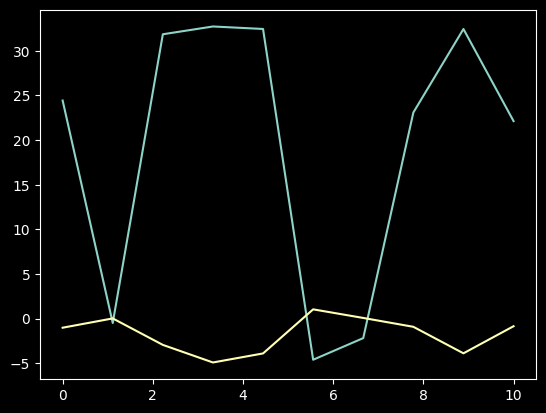

In [16]:
plt.plot(t_test, predict, label='predicted drift x')
plt.plot(t_test, x_test, label='truth')
print(predict)

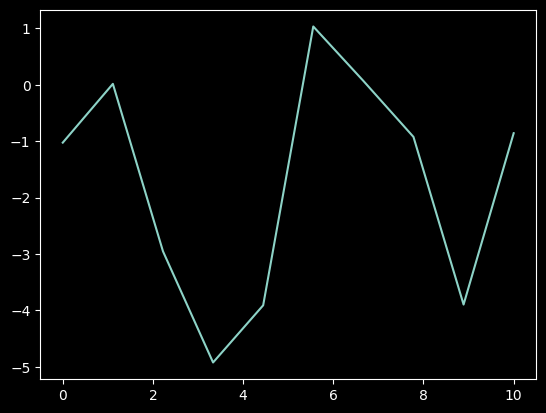

In [15]:
plt.plot(t_test, x_test, label='predicted drift y')
# plt.plot(t_test, y_test, label='true drift y')